# Credit Risk Prediction - Modeling & Evaluation

Preprocessing, model training, and evaluation pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, f1_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data

In [2]:
df = pd.read_excel('../data/raw/default of credit card clients.xls', header=1, engine='xlrd')
df.rename(columns={'default payment next month': 'default'}, inplace=True)
df.drop('ID', axis=1, inplace=True)

TARGET = 'default'
X = df.drop(TARGET, axis=1)
y = df[TARGET]
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Default rate: {y.mean():.2%}")


Features: 23, Samples: 30000
Default rate: 22.12%


## 2. Feature Engineering

In [3]:
# Payment delay features
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X['avg_delay'] = X[pay_cols].mean(axis=1)
X['max_delay'] = X[pay_cols].max(axis=1)
X['delay_std'] = X[pay_cols].std(axis=1)
X['total_delay_months'] = (X[pay_cols] > 0).sum(axis=1)

# Bill amount features
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
X['avg_bill'] = X[bill_cols].mean(axis=1)
X['bill_trend'] = X['BILL_AMT1'] - X['BILL_AMT6']

# Payment amount features
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
X['avg_pay_amt'] = X[pay_amt_cols].mean(axis=1)
X['pay_ratio'] = X['avg_pay_amt'] / (X['avg_bill'] + 1)

# Credit utilization
X['credit_util'] = X['BILL_AMT1'] / (X['LIMIT_BAL'] + 1)

print(f"Features after engineering: {X.shape[1]}")
print(f"New features: avg_delay, max_delay, delay_std, total_delay_months,")
print(f"              avg_bill, bill_trend, avg_pay_amt, pay_ratio, credit_util")


Features after engineering: 32
New features: avg_delay, max_delay, delay_std, total_delay_months,
              avg_bill, bill_trend, avg_pay_amt, pay_ratio, credit_util


## 3. Imputation & Winsorization

In [4]:
X.fillna(0, inplace=True)
print(f"NaN after imputation: {X.isnull().sum().sum()}")

def winsorize(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

numeric_cols = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    X[col] = winsorize(X[col])
print("Winsorization applied (1st-99th percentile)")


NaN after imputation: 0
Winsorization applied (1st-99th percentile)


## 4. Train/Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Train: {X_train.shape[0]} samples (default: {y_train.mean():.2%})")
print(f"Test:  {X_test.shape[0]} samples (default: {y_test.mean():.2%})")


Train: 24000 samples (default: 22.12%)
Test:  6000 samples (default: 22.12%)


## 5. SMOTE Oversampling

In [6]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {X_train_sm.shape[0]} samples (default: {y_train_sm.mean():.2%})")


After SMOTE: 37382 samples (default: 50.00%)


## 6. Model Training with Cross-Validation

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                              eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                                verbose=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=" * 70)
print(f"{'Model':<25} {'CV AUC':<12} {'CV Std':<10} {'Test AUC':<12}")
print("=" * 70)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
    model.fit(X_train_sm, y_train_sm)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
                     'test_auc': test_auc, 'model': model, 'y_prob': y_prob}
    print(f"{name:<25} {cv_scores.mean():<12.4f} {cv_scores.std():<10.4f} {test_auc:<12.4f}")

print("=" * 70)
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(f"\nBest model: {best_model_name} (Test AUC: {results[best_model_name]['test_auc']:.4f})")


Model                     CV AUC       CV Std     Test AUC    


Logistic Regression       0.7671       0.0046     0.7450      


Random Forest             0.8636       0.0034     0.7729      


XGBoost                   0.9301       0.0020     0.7607      


LightGBM                  0.9344       0.0016     0.7659      

Best model: Random Forest (Test AUC: 0.7729)


## 7. ROC Curves

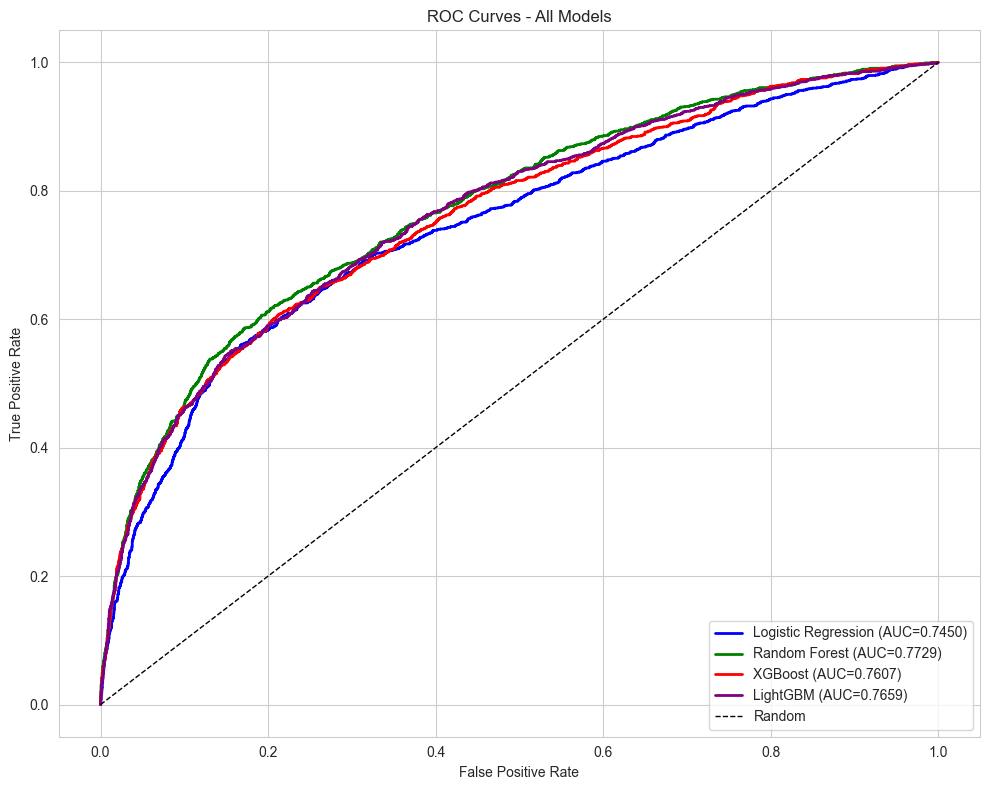

In [8]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['test_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Precision-Recall Curves

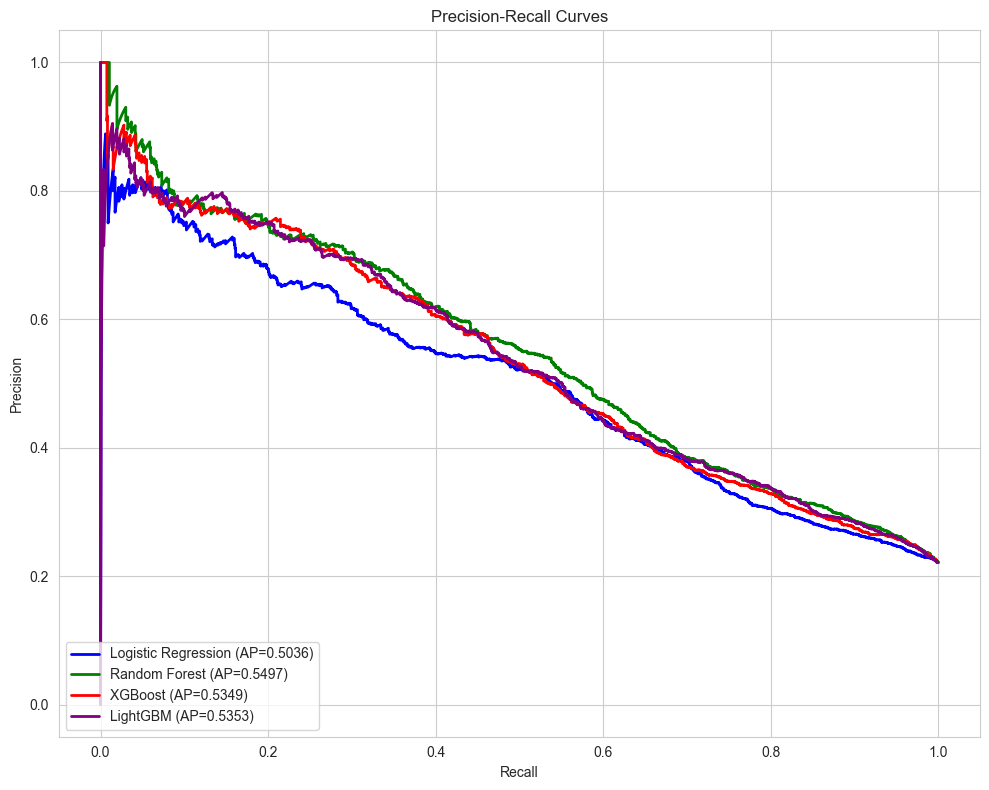

In [9]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple']

for (name, res), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall, precision, color=color, lw=2, label=f"{name} (AP={ap:.4f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('../reports/figures/07_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Confusion Matrix (Best Model)

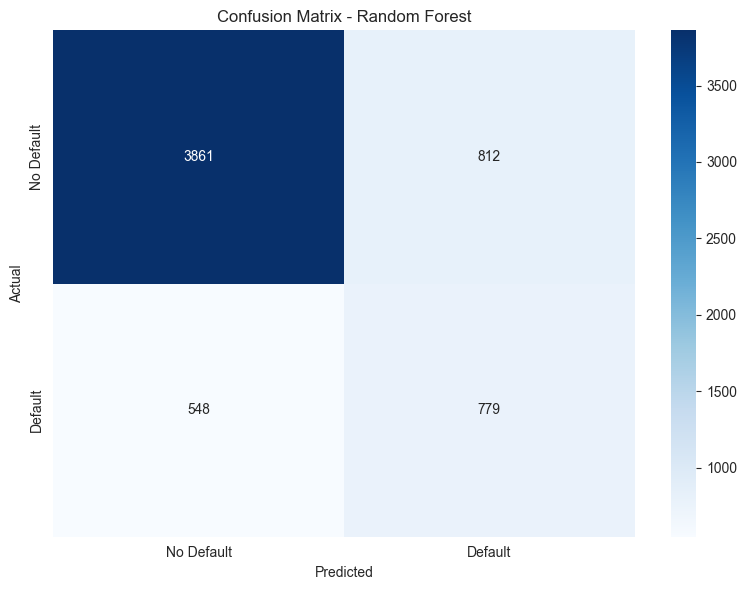


Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.83      0.85      4673
     Default       0.49      0.59      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



In [10]:
best_model = results[best_model_name]['model']
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../reports/figures/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))


## 10. Threshold Analysis

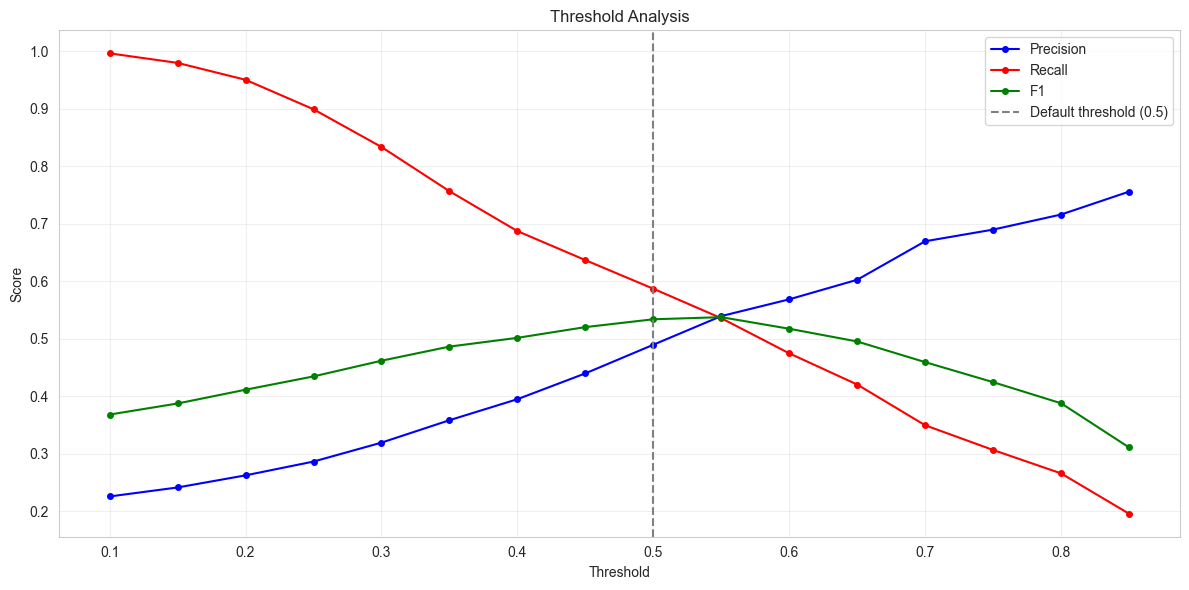

Optimal threshold (max F1): 0.55
  Precision: 0.5395
  Recall: 0.5358
  F1: 0.5376


In [11]:
y_prob_best = results[best_model_name]['y_prob']
thresholds = np.arange(0.1, 0.9, 0.05)
metrics = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    metrics.append({
        'threshold': t,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0
    })

metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(12, 6))
plt.plot(metrics_df['threshold'], metrics_df['precision'], 'b-o', label='Precision', markersize=4)
plt.plot(metrics_df['threshold'], metrics_df['recall'], 'r-o', label='Recall', markersize=4)
plt.plot(metrics_df['threshold'], metrics_df['f1'], 'g-o', label='F1', markersize=4)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/09_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_idx = metrics_df['f1'].idxmax()
print(f"Optimal threshold (max F1): {metrics_df.loc[optimal_idx, 'threshold']:.2f}")
print(f"  Precision: {metrics_df.loc[optimal_idx, 'precision']:.4f}")
print(f"  Recall: {metrics_df.loc[optimal_idx, 'recall']:.4f}")
print(f"  F1: {metrics_df.loc[optimal_idx, 'f1']:.4f}")


## 11. Model Serialization

In [12]:
for name, res in results.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(res['model'], f'../models/{safe_name}.pkl')
    print(f"Saved: models/{safe_name}.pkl")

joblib.dump(scaler, '../models/scaler.pkl')
print("Saved: models/scaler.pkl")


Saved: models/logistic_regression.pkl
Saved: models/random_forest.pkl
Saved: models/xgboost.pkl
Saved: models/lightgbm.pkl
Saved: models/scaler.pkl


## 12. Gini & KS Statistics

In [13]:
def gini_coef(y_true, y_prob):
    arr = np.array([y_true, y_prob]).T
    arr = arr[np.argsort(arr[:, 1])]
    n = len(arr)
    cum_y = np.cumsum(arr[:, 0])
    return 1 - 2 * np.sum(cum_y) / (n * np.sum(arr[:, 0])) + 1/n

def ks_stat(y_true, y_prob):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return max(tpr - fpr)

print(f"{'Model':<25} {'Gini':<10} {'KS':<10}")
print("=" * 45)
for name, res in results.items():
    gini = gini_coef(y_test, res['y_prob'])
    ks = ks_stat(y_test, res['y_prob'])
    print(f"{name:<25} {gini:<10.4f} {ks:<10.4f}")


Model                     Gini       KS        
Logistic Regression       0.3816     0.3929    
Random Forest             0.4251     0.4145    
XGBoost                   0.4061     0.3954    
LightGBM                  0.4141     0.3951    
